# CVAE - Alinc2026

# Etapa 3

In [1]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

DB_PATH = "../db/tfm_vocs.db"
PARQUET_PATH = "../db/data/processed/abundancias_alinc2026.csv"
DATASET_ORIGIN = "Alinc2026"

In [2]:
import pickle
import numpy as np
from pathlib import Path

MODELS_DIR = Path("../models")

def export_cvae(dataset_slug, encoder, decoder, scaler, compound_ids,
                 iso_forest=None, autoencoder=None,
                 scores_loo=None, errores_loo_ae=None, meta=None):
    out = MODELS_DIR / dataset_slug
    out.mkdir(parents=True, exist_ok=True)
    encoder.save(out / "cvae_encoder.keras")
    decoder.save(out / "cvae_decoder.keras")

    with open(out / "scaler.pkl", "wb") as f:
        pickle.dump(scaler, f)
    with open(out / "compound_ids.pkl", "wb") as f:
        pickle.dump(list(compound_ids), f)

    if autoencoder is not None:
        autoencoder.save(out / "autoencoder.keras")
    if iso_forest is not None:
        with open(out / "isolation_forest.pkl", "wb") as f:
            pickle.dump(iso_forest, f)
    if scores_loo is not None:
        np.save(out / "scores_loo.npy", scores_loo)
    if errores_loo_ae is not None:
        np.save(out / "errores_loo_ae.npy", errores_loo_ae)
    if meta:
        with open(out / "cvae_meta.pkl", "wb") as f:
            pickle.dump(meta, f)

    print(f"Exportado: {dataset_slug} -> {out}")

In [3]:
SEED = 42
tf.keras.utils.set_random_seed(SEED)

### Carga de datos

In [4]:
con = sqlite3.connect(DB_PATH)

muestras = pd.read_sql(
    f"SELECT * FROM muestras WHERE dataset_origin = '{DATASET_ORIGIN}'", con
)
compuestos = pd.read_sql(
    f"SELECT * FROM compuestos WHERE dataset_origin = '{DATASET_ORIGIN}'", con
)
abundancias = pd.read_csv(PARQUET_PATH)

con.close()

print("Muestras:", muestras.shape)
print("Compuestos:", compuestos.shape)
print("Abundancias:", abundancias.shape)
print("\nphysiological_state:")
print(muestras["physiological_state"].value_counts())
print("\nNulos en abundancia:", abundancias["abundancia"].isna().sum())

muestras.head()

Muestras: (15, 19)
Compuestos: (23, 15)
Abundancias: (345, 4)

physiological_state:
physiological_state
herbivory_only          5
biocontrol_herbivory    5
control                 5
Name: count, dtype: int64

Nulos en abundancia: 0


,sample_id,species,genotype,genotype_notes,microorganism,strain,physiological_state,dataset_origin,doi,analytical_technique,timepoint,tissue,experiment_replicate,biological_replicate,load_date,validation_status,intended_use,eje_biologico,metadata_extra
0,alinc2026_fo_r01,Solanum lycopersicum,None,None,None,None,herbivory_only,Alinc2026,10.1002/ps.70436,"HS-GC-MS (Porapak Q, 24h, Agilent 6890/MS5973)",None,"whole plant (headspace, cylindrical glass cham...",None,1,2026-07-05,pendiente_validacion,classifier,herbivoria_biocontrol,"{""fungal_inoculant"": null, ""herbivore_species""..."
1,alinc2026_fo_r02,Solanum lycopersicum,None,None,None,None,herbivory_only,Alinc2026,10.1002/ps.70436,"HS-GC-MS (Porapak Q, 24h, Agilent 6890/MS5973)",None,"whole plant (headspace, cylindrical glass cham...",None,2,2026-07-05,pendiente_validacion,classifier,herbivoria_biocontrol,"{""fungal_inoculant"": null, ""herbivore_species""..."
2,alinc2026_fo_r03,Solanum lycopersicum,None,None,None,None,herbivory_only,Alinc2026,10.1002/ps.70436,"HS-GC-MS (Porapak Q, 24h, Agilent 6890/MS5973)",None,"whole plant (headspace, cylindrical glass cham...",None,3,2026-07-05,pendiente_validacion,classifier,herbivoria_biocontrol,"{""fungal_inoculant"": null, ""herbivore_species""..."
3,alinc2026_fo_r04,Solanum lycopersicum,None,None,None,None,herbivory_only,Alinc2026,10.1002/ps.70436,"HS-GC-MS (Porapak Q, 24h, Agilent 6890/MS5973)",None,"whole plant (headspace, cylindrical glass cham...",None,4,2026-07-05,pendiente_validacion,classifier,herbivoria_biocontrol,"{""fungal_inoculant"": null, ""herbivore_species""..."
4,alinc2026_fo_r05,Solanum lycopersicum,None,None,None,None,herbivory_only,Alinc2026,10.1002/ps.70436,"HS-GC-MS (Porapak Q, 24h, Agilent 6890/MS5973)",None,"whole plant (headspace, cylindrical glass cham...",None,5,2026-07-05,pendiente_validacion,classifier,herbivoria_biocontrol,"{""fungal_inoculant"": null, ""herbivore_species""..."


### Preprocesamiento

In [5]:
# Detección de  contamienantes
pd.set_option("display.max_rows", None)
compuestos[["compuesto_id", "name_original", "cas", "pubchem_cid"]]


,compuesto_id,name_original,cas,pubchem_cid
0,alinc2026_cmp001,α-tujene,None,17868.0
1,alinc2026_cmp002,α-pinene,None,6654.0
2,alinc2026_cmp003,"1,3,5-cycloheptatriene, 3,7,7-trimethyl-",None,576718.0
3,alinc2026_cmp004,β-pinene,None,14896.0
4,alinc2026_cmp005,isolimonene,None,521268.0
5,alinc2026_cmp006,β-myrcene,None,31253.0
6,alinc2026_cmp007,(+)-2-carene,None,78249.0
7,alinc2026_cmp008,α-phellandrene,None,7460.0
8,alinc2026_cmp009,α-terpinene,None,7462.0
9,alinc2026_cmp010,p-cymene,None,7463.0


In [6]:
#Pivot
wide = abundancias.pivot(index="sample_id", columns="compuesto_id", values="abundancia")
print("Shape wide:", wide.shape)
print("Nulos en wide:", wide.isna().sum().sum())
wide.head()

Shape wide: (15, 23)
Nulos en wide: 0


compuesto_id,alinc2026_cmp001,alinc2026_cmp002,alinc2026_cmp003,alinc2026_cmp004,alinc2026_cmp005,alinc2026_cmp006,alinc2026_cmp007,alinc2026_cmp008,alinc2026_cmp009,alinc2026_cmp010,...,alinc2026_cmp014,alinc2026_cmp015,alinc2026_cmp016,alinc2026_cmp017,alinc2026_cmp018,alinc2026_cmp019,alinc2026_cmp020,alinc2026_cmp021,alinc2026_cmp022,alinc2026_cmp023
sample_id,,,,,,,,,,,,,,,,,,,,,
alinc2026_ctrl_r01,363320.0,1828108.0,640409.0,619726.0,64030.0,88655.0,8200210.0,575166.0,17600.0,469485.0,...,249924.0,58456.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
alinc2026_ctrl_r02,98836.0,4771342.0,1750503.0,601949.0,0.0,0.0,18563027.0,2409973.0,542976.0,636074.0,...,113458.0,88754.0,0.0,0.0,0.0,141977.0,0.0,0.0,0.0,0.0
alinc2026_ctrl_r03,2797790.0,261567594.0,133546724.0,8536250.0,16567697.0,6294659.0,876114021.0,195597674.0,67769177.0,15704428.0,...,14979864.0,1920889.0,810901.0,633279.0,35125565.0,662694.0,697962.0,947138.0,307144.0,421150.0
alinc2026_ctrl_r04,506541.0,52014715.0,40454538.0,1388862.0,3241750.0,798573.0,222237528.0,45228810.0,12246295.0,6705961.0,...,3125942.0,290422.0,172670.0,0.0,3896241.0,129010.0,78823.0,384523.0,0.0,200506.0
alinc2026_ctrl_r05,0.0,2692877.0,1582049.0,303568.0,644533.0,998457.0,11892937.0,1784421.0,263097.0,937077.0,...,72466.0,118392.0,0.0,0.0,307539.0,0.0,0.0,88862.0,0.0,23767.0


In [7]:
#Log1p
X_log = np.log1p(wide.values)
print("X_log shape:", X_log.shape)

X_log shape: (15, 23)


In [8]:
#Condicionamiento + split estratificado
estado = muestras.set_index("sample_id").loc[wide.index, "physiological_state"]

# Orden de categorías para que control sea la referencia 
estado_cat = pd.Categorical(estado, categories=["control", "herbivory_only", "biocontrol_herbivory"])
cond_dummies = pd.get_dummies(estado_cat, drop_first=True).astype(float)
print("Columnas de condición:", cond_dummies.columns.tolist())
cond_dummies.head()

Columnas de condición: ['herbivory_only', 'biocontrol_herbivory']


,herbivory_only,biocontrol_herbivory
0,0.0,0.0
1,0.0,0.0
2,0.0,0.0
3,0.0,0.0
4,0.0,0.0


In [9]:
#División tr/ts
X_train, X_val, y_train, y_val = train_test_split(
    X_log, cond_dummies.values,
    test_size=0.33, stratify=estado, random_state=42
)

print("X_train:", X_train.shape, " X_val:", X_val.shape)
print("y_train:", y_train.shape, " y_val:", y_val.shape)

X_train: (10, 23)  X_val: (5, 23)
y_train: (10, 2)  y_val: (5, 2)


In [10]:
#Estandarización
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)

print(X_train_s.shape, X_val_s.shape)

(10, 23) (5, 23)


## Encoder

In [11]:
input_dim = X_train_s.shape[1]
cond_dim = y_train.shape[1]
latent_dim = 2

def sampling(args):
    z_mean, z_log_var = args
    eps = tf.random.normal(shape=tf.shape(z_mean))
    return z_mean + tf.exp(0.5 * z_log_var) * eps
    
encoder_inputs = keras.Input(shape=(input_dim,), name="x_input")
encoder_cond = keras.Input(shape=(cond_dim,), name="cond_input")
x = layers.concatenate([encoder_inputs, encoder_cond])
x = layers.Dense(8, activation="relu")(x)
x = layers.Dense(4, activation="relu")(x)
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
z = layers.Lambda(sampling, name="z")([z_mean, z_log_var])
encoder = keras.Model([encoder_inputs, encoder_cond], [z_mean, z_log_var, z], name="encoder")
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ x_input (InputLayer)          │ (None, 23)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ cond_input (InputLayer)       │ (None, 2)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 25)                │               0 │ x_input[0][0],             │
│                               │                           │                 │ cond_input[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 8)                 │             208 │ concatenate[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 4)                 │              36 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ z_mean (Dense)                │ (None, 2)                 │              10 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ z_log_var (Dense)             │ (None, 2)                 │              10 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ z (Lambda)                    │ (None, 2)                 │               0 │ z_mean[0][0],              │
│                               │                           │                 │ z_log_var[0][0]            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 264 (1.03 KB)

 Trainable params: 264 (1.03 KB)

 Non-trainable params: 0 (0.00 B)

## Decoder

In [12]:
latent_inputs = keras.Input(shape=(latent_dim,), name="z_input")
decoder_cond = keras.Input(shape=(cond_dim,), name="cond_input_dec")
x = layers.concatenate([latent_inputs, decoder_cond])
x = layers.Dense(4, activation="relu")(x)
x = layers.Dense(8, activation="relu")(x)
decoder_outputs = layers.Dense(input_dim, activation="linear")(x)
decoder = keras.Model([latent_inputs, decoder_cond], decoder_outputs, name="decoder")
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ z_input (InputLayer)          │ (None, 2)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ cond_input_dec (InputLayer)   │ (None, 2)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_1 (Concatenate)   │ (None, 4)                 │               0 │ z_input[0][0],             │
│                               │                           │                 │ cond_input_dec[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 4)                 │              20 │ concatenate_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_3 (Dense)               │ (None, 8)                 │              40 │ dense_2[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_4 (Dense)               │ (None, 23)                │             207 │ dense_3[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 267 (1.04 KB)

 Trainable params: 267 (1.04 KB)

 Non-trainable params: 0 (0.00 B)

## CVAE completo

In [13]:
class CVAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="loss")
        self.recon_loss_tracker = keras.metrics.Mean(name="recon_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")
        self.beta = tf.Variable(1.0, trainable=False, dtype=tf.float32)

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def _compute_losses(self, x, cond):
        z_mean, z_log_var, z = self.encoder([x, cond])
        reconstruction = self.decoder([z, cond])
        recon_loss = tf.reduce_mean(tf.reduce_sum(tf.square(x - reconstruction), axis=1))
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
        )
        total_loss = recon_loss + self.beta * kl_loss
        return total_loss, recon_loss, kl_loss

    def train_step(self, data):
        x, cond = data
        with tf.GradientTape() as tape:
            total_loss, recon_loss, kl_loss = self._compute_losses(x, cond)
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        x, cond = data
        total_loss, recon_loss, kl_loss = self._compute_losses(x, cond)
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

## Entrenamiento

In [14]:
class KLWarmup(keras.callbacks.Callback):
    def __init__(self, total_epochs):
        super().__init__()
        self.total_epochs = total_epochs

    def on_epoch_begin(self, epoch, logs=None):
        new_beta = min(1.0, epoch / (self.total_epochs * 0.5))
        self.model.beta.assign(new_beta)

cvae = CVAE(encoder, decoder)
cvae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))

EPOCHS = 800
BATCH_SIZE = 8

history = cvae.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[KLWarmup(EPOCHS)],
    verbose=0,
)

print("Entrenamiento terminado (modelo final).")
print({k: v[-1] for k, v in history.history.items()})

Entrenamiento terminado (modelo final).
{'kl_loss': 1.5152959823608398, 'loss': 6.736653804779053, 'recon_loss': 5.221357822418213, 'val_kl_loss': 2.2736704349517822, 'val_loss': 23.242420196533203, 'val_recon_loss': 20.96875}


## Curva de pérdida

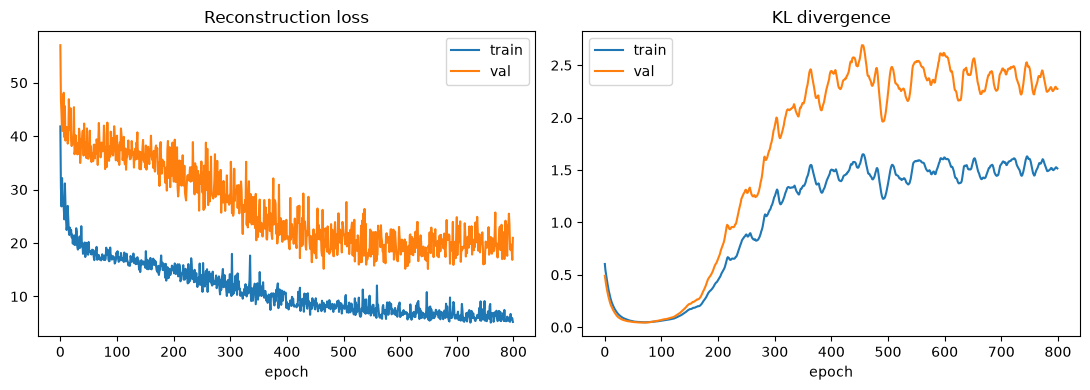

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history.history["recon_loss"], label="train")
axes[0].plot(history.history["val_recon_loss"], label="val")
axes[0].set_title("Reconstruction loss")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(history.history["kl_loss"], label="train")
axes[1].plot(history.history["val_kl_loss"], label="val")
axes[1].set_title("KL divergence")
axes[1].set_xlabel("epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

In [16]:
import numpy as np

n_ultimas = 50
print("Promedio últimas", n_ultimas, "épocas:")
print("recon_loss (train):", np.mean(history.history["recon_loss"][-n_ultimas:]))
print("recon_loss (val):", np.mean(history.history["val_recon_loss"][-n_ultimas:]))
print("kl_loss (train):", np.mean(history.history["kl_loss"][-n_ultimas:]))
print("kl_loss (val):", np.mean(history.history["val_kl_loss"][-n_ultimas:]))

Promedio últimas 50 épocas:
recon_loss (train): 6.159556932449341
recon_loss (val): 20.03095069885254
kl_loss (train): 1.5257408118247986
kl_loss (val): 2.318809585571289


## Chequeo de reconstrucciónm

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


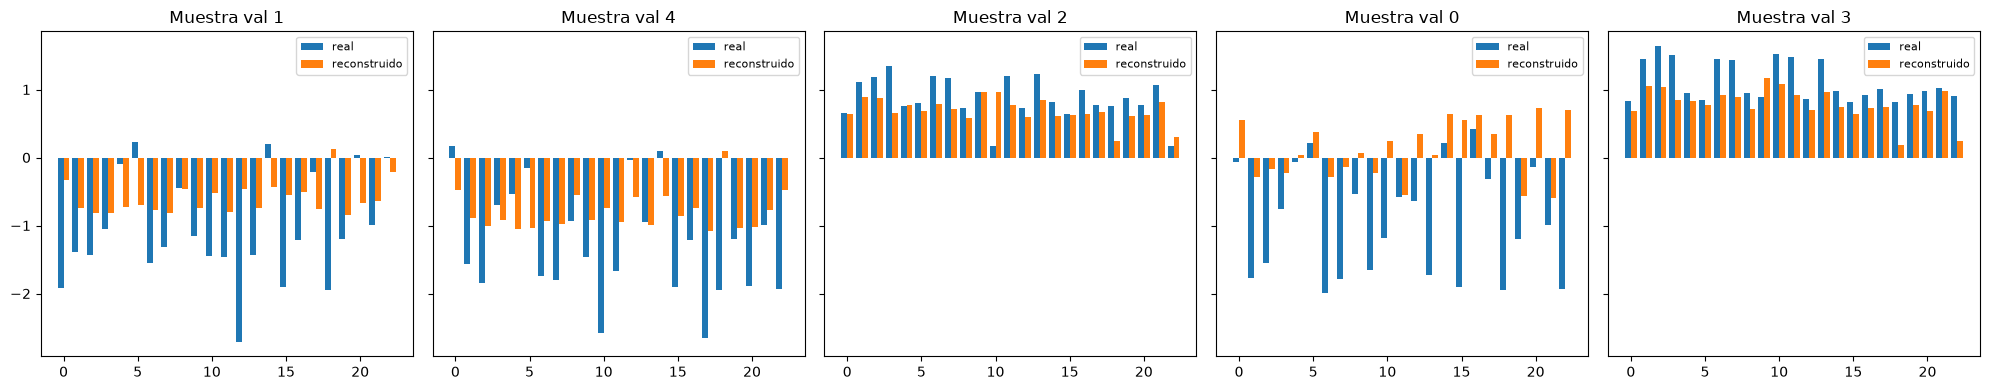

In [17]:
n_muestras = 5
idx_muestra = np.random.choice(len(X_val_s), n_muestras, replace=False)

z_mean_val, z_log_var_val, z_val = encoder.predict([X_val_s, y_val])
reconstruccion_val = decoder.predict([z_val, y_val])

fig, axes = plt.subplots(1, n_muestras, figsize=(4 * n_muestras, 4), sharey=True)
for ax, i in zip(axes, idx_muestra):
    ax.bar(np.arange(input_dim) - 0.2, X_val_s[i], width=0.4, label="real")
    ax.bar(np.arange(input_dim) + 0.2, reconstruccion_val[i], width=0.4, label="reconstruido")
    ax.set_title(f"Muestra val {i}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Espacio latente

Labels de validación: ['herbivory_only' 'control' 'biocontrol_herbivory' 'herbivory_only'
 'control']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


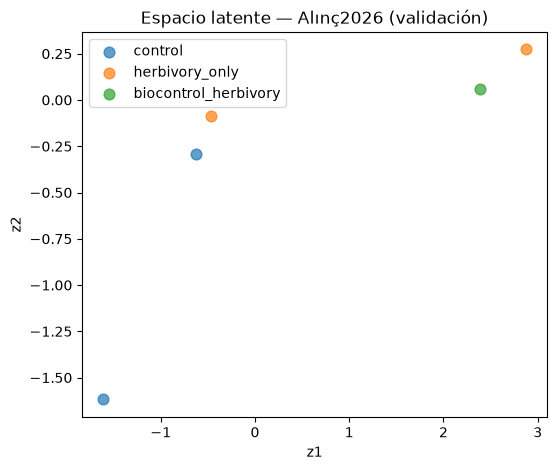

Silhouette score (validación): -0.17546352744102478


In [18]:
from sklearn.metrics import silhouette_score

# Reconstruir a partir de las dummies
def dummies_a_label(fila):
    if fila[0] == 1:
        return "herbivory_only"
    elif fila[1] == 1:
        return "biocontrol_herbivory"
    else:
        return "control"

labels_val = np.array([dummies_a_label(fila) for fila in y_val])
print("Labels de validación:", labels_val)

z_mean_val, _, _ = encoder.predict([X_val_s, y_val])

plt.figure(figsize=(6, 5))
for lbl in ["control", "herbivory_only", "biocontrol_herbivory"]:
    mask = labels_val == lbl
    plt.scatter(z_mean_val[mask, 0], z_mean_val[mask, 1], label=lbl, alpha=0.7, s=60)

plt.xlabel("z1")
plt.ylabel("z2")
plt.legend()
plt.title("Espacio latente — Alınç2026 (validación)")
plt.show()

sil = silhouette_score(z_mean_val, labels_val)
print("Silhouette score (validación):", sil)

## Exploración del gradiente

In [19]:
z_fixed = np.zeros((1, latent_dim))
n_steps = 11
c_steps = np.linspace(0, 1, n_steps).reshape(-1, 1)
z_repeated = np.repeat(z_fixed, n_steps, axis=0)

# control a herbivory_only 
cond_herb = np.hstack([c_steps, np.zeros((n_steps, 1))])
perfiles_herb = decoder.predict([z_repeated, cond_herb])
delta_herb = perfiles_herb[-1] - perfiles_herb[0]

# control a biocontrol_herbivory 
cond_bio = np.hstack([np.zeros((n_steps, 1)), c_steps])
perfiles_bio = decoder.predict([z_repeated, cond_bio])
delta_bio = perfiles_bio[-1] - perfiles_bio[0]

compound_ids = wide.columns

cambios_herb = pd.DataFrame({"compuesto_id": compound_ids, "delta": delta_herb})
cambios_herb = cambios_herb.merge(compuestos[["compuesto_id", "name_original", "pubchem_cid"]], on="compuesto_id", how="left")
cambios_herb = cambios_herb.reindex(cambios_herb["delta"].abs().sort_values(ascending=False).index)

cambios_bio = pd.DataFrame({"compuesto_id": compound_ids, "delta": delta_bio})
cambios_bio = cambios_bio.merge(compuestos[["compuesto_id", "name_original", "pubchem_cid"]], on="compuesto_id", how="left")
cambios_bio = cambios_bio.reindex(cambios_bio["delta"].abs().sort_values(ascending=False).index)

print("Top 10 — control a herbivory_only:")
display(cambios_herb.head(10))

print("\nTop 10 — control a biocontrol_herbivory:")
display(cambios_bio.head(10))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Top 10 — control a herbivory_only:


,compuesto_id,delta,name_original,pubchem_cid
14,alinc2026_cmp015,0.598116,α-terpinene,7462.0
0,alinc2026_cmp001,0.485324,α-tujene,17868.0
20,alinc2026_cmp021,0.477971,humulene,5281520.0
16,alinc2026_cmp017,0.457260,(-)-β-elemene,6918391.0
12,alinc2026_cmp013,0.447043,gamma terpinene,7461.0
3,alinc2026_cmp004,0.406134,β-pinene,14896.0
7,alinc2026_cmp008,0.403212,α-phellandrene,7460.0
5,alinc2026_cmp006,0.374742,β-myrcene,31253.0
8,alinc2026_cmp009,0.347088,α-terpinene,7462.0
18,alinc2026_cmp019,0.338603,γ-elemene,6432312.0



Top 10 — control a biocontrol_herbivory:


,compuesto_id,delta,name_original,pubchem_cid
14,alinc2026_cmp015,-0.473424,α-terpinene,7462.0
20,alinc2026_cmp021,-0.457683,humulene,5281520.0
16,alinc2026_cmp017,-0.410486,(-)-β-elemene,6918391.0
15,alinc2026_cmp016,-0.390050,Unknown 1,NaN
0,alinc2026_cmp001,-0.388675,α-tujene,17868.0
17,alinc2026_cmp018,-0.359315,caryophyllene,5281515.0
5,alinc2026_cmp006,-0.336126,β-myrcene,31253.0
10,alinc2026_cmp011,-0.323124,limonene,22311.0
22,alinc2026_cmp023,-0.305983,caryophyllene oxide,1742210.0
12,alinc2026_cmp013,-0.304427,gamma terpinene,7461.0


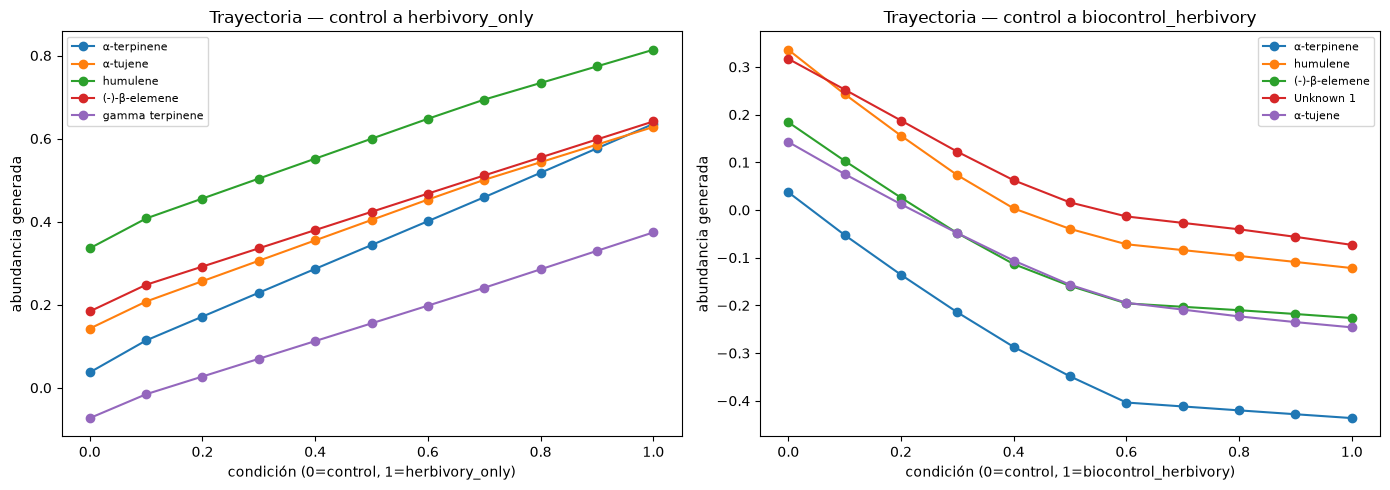

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top5_herb = cambios_herb.head(5)["compuesto_id"].tolist()
idx_top5_herb = [list(compound_ids).index(cid) for cid in top5_herb]

for i, cid in zip(idx_top5_herb, top5_herb):
    nombre = compuestos.loc[compuestos["compuesto_id"] == cid, "name_original"].values
    etiqueta = nombre[0] if len(nombre) else cid
    axes[0].plot(c_steps.flatten(), perfiles_herb[:, i], marker="o", label=etiqueta)

axes[0].set_xlabel("condición (0=control, 1=herbivory_only)")
axes[0].set_ylabel("abundancia generada")
axes[0].legend(fontsize=8)
axes[0].set_title("Trayectoria — control a herbivory_only")

top5_bio = cambios_bio.head(5)["compuesto_id"].tolist()
idx_top5_bio = [list(compound_ids).index(cid) for cid in top5_bio]

for i, cid in zip(idx_top5_bio, top5_bio):
    nombre = compuestos.loc[compuestos["compuesto_id"] == cid, "name_original"].values
    etiqueta = nombre[0] if len(nombre) else cid
    axes[1].plot(c_steps.flatten(), perfiles_bio[:, i], marker="o", label=etiqueta)

axes[1].set_xlabel("condición (0=control, 1=biocontrol_herbivory)")
axes[1].set_ylabel("abundancia generada")
axes[1].legend(fontsize=8)
axes[1].set_title("Trayectoria — control a biocontrol_herbivory")

plt.tight_layout()
plt.show()

# Etapa 4

In [21]:
#Isolation Forest
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import LeaveOneOut

X_real_alinc = np.vstack([X_train_s, X_val_s])
n_real_alinc = X_real_alinc.shape[0]
print(f"Muestras reales (Alınç tomate): {n_real_alinc}")

iso_final_alinc = IsolationForest(n_estimators=200, contamination="auto", random_state=SEED)
iso_final_alinc.fit(X_real_alinc)

loo = LeaveOneOut()
scores_loo_alinc = np.zeros(n_real_alinc)
for train_idx, test_idx in loo.split(X_real_alinc):
    iso_fold = IsolationForest(n_estimators=200, contamination="auto", random_state=SEED)
    iso_fold.fit(X_real_alinc[train_idx])
    scores_loo_alinc[test_idx[0]] = -iso_fold.score_samples(X_real_alinc[test_idx])[0]

print("Distribución LOO Isolation Forest (Alınç):")
print(pd.Series(scores_loo_alinc).describe())

Muestras reales (Alınç tomate): 15
Distribución LOO Isolation Forest (Alınç):
count    15.000000
mean      0.525674
std       0.028216
min       0.487551
25%       0.500528
50%       0.520616
75%       0.550509
max       0.570408
dtype: float64


In [22]:
# % de la distrib de referncia queda debajo de score
def percentil_vs_referencia(score, referencia):
    return (referencia < score).mean() * 100

score_herb_alinc = -iso_final_alinc.score_samples(perfiles_herb)
score_bio_alinc = -iso_final_alinc.score_samples(perfiles_bio)

resultado_alinc_herb = pd.DataFrame({
    "condicion": "herbivory_only",
    "paso_condicion": c_steps.flatten(),
    "score_isolation_forest": score_herb_alinc,
    "percentil_if_vs_reales": [percentil_vs_referencia(s, scores_loo_alinc) for s in score_herb_alinc],
})
resultado_alinc_bio = pd.DataFrame({
    "condicion": "biocontrol_herbivory",
    "paso_condicion": c_steps.flatten(),
    "score_isolation_forest": score_bio_alinc,
    "percentil_if_vs_reales": [percentil_vs_referencia(s, scores_loo_alinc) for s in score_bio_alinc],
})

resultado_alinc_bio

,condicion,paso_condicion,score_isolation_forest,percentil_if_vs_reales
0,biocontrol_herbivory,0.0,0.472541,0.000000
1,biocontrol_herbivory,0.1,0.476978,0.000000
2,biocontrol_herbivory,0.2,0.480247,0.000000
3,biocontrol_herbivory,0.3,0.482936,0.000000
4,biocontrol_herbivory,0.4,0.483172,0.000000
5,biocontrol_herbivory,0.5,0.484426,0.000000
6,biocontrol_herbivory,0.6,0.488272,6.666667
7,biocontrol_herbivory,0.7,0.488643,6.666667
8,biocontrol_herbivory,0.8,0.485789,0.000000
9,biocontrol_herbivory,0.9,0.485713,0.000000


In [23]:
resultado_alinc_herb

,condicion,paso_condicion,score_isolation_forest,percentil_if_vs_reales
0,herbivory_only,0.0,0.472541,0.0
1,herbivory_only,0.1,0.475941,0.0
2,herbivory_only,0.2,0.474108,0.0
3,herbivory_only,0.3,0.471165,0.0
4,herbivory_only,0.4,0.473223,0.0
5,herbivory_only,0.5,0.471780,0.0
6,herbivory_only,0.6,0.470477,0.0
7,herbivory_only,0.7,0.475250,0.0
8,herbivory_only,0.8,0.475325,0.0
9,herbivory_only,0.9,0.475632,0.0


In [24]:
# Extrapolación para ver mas allá en una condición mayor a infected.
n_steps_extra = 11
c_steps_extra = np.linspace(1.0, 2.0, n_steps_extra).reshape(-1, 1)
z_repeated_extra = np.repeat(z_fixed, n_steps_extra, axis=0)

cond_herb_extra = np.hstack([c_steps_extra, np.zeros((n_steps_extra, 1))])
perfiles_extrap_alinc_herb = decoder.predict([z_repeated_extra, cond_herb_extra])
score_extrap_alinc_herb = -iso_final_alinc.score_samples(perfiles_extrap_alinc_herb)

cond_bio_extra = np.hstack([np.zeros((n_steps_extra, 1)), c_steps_extra])
perfiles_extrap_alinc_bio = decoder.predict([z_repeated_extra, cond_bio_extra])
score_extrap_alinc_bio = -iso_final_alinc.score_samples(perfiles_extrap_alinc_bio)

resultado_extrap_alinc_herb = pd.DataFrame({
    "condicion": "herbivory_only",
    "paso_condicion": c_steps_extra.flatten(),
    "score_isolation_forest": score_extrap_alinc_herb,
    "percentil_if_vs_reales": [percentil_vs_referencia(s, scores_loo_alinc) for s in score_extrap_alinc_herb],
})
resultado_extrap_alinc_bio = pd.DataFrame({
    "condicion": "biocontrol_herbivory",
    "paso_condicion": c_steps_extra.flatten(),
    "score_isolation_forest": score_extrap_alinc_bio,
    "percentil_if_vs_reales": [percentil_vs_referencia(s, scores_loo_alinc) for s in score_extrap_alinc_bio],
})
resultado_extrap_alinc_bio

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


,condicion,paso_condicion,score_isolation_forest,percentil_if_vs_reales
0,biocontrol_herbivory,1.0,0.486582,0.000000
1,biocontrol_herbivory,1.1,0.486582,0.000000
2,biocontrol_herbivory,1.2,0.486582,0.000000
3,biocontrol_herbivory,1.3,0.486385,0.000000
4,biocontrol_herbivory,1.4,0.487985,6.666667
5,biocontrol_herbivory,1.5,0.487561,6.666667
6,biocontrol_herbivory,1.6,0.487854,6.666667
7,biocontrol_herbivory,1.7,0.487038,0.000000
8,biocontrol_herbivory,1.8,0.487407,0.000000
9,biocontrol_herbivory,1.9,0.487092,0.000000


In [25]:
resultado_extrap_alinc_herb

,condicion,paso_condicion,score_isolation_forest,percentil_if_vs_reales
0,herbivory_only,1.0,0.475430,0.000000
1,herbivory_only,1.1,0.475004,0.000000
2,herbivory_only,1.2,0.477929,0.000000
3,herbivory_only,1.3,0.477664,0.000000
4,herbivory_only,1.4,0.479435,0.000000
5,herbivory_only,1.5,0.482376,0.000000
6,herbivory_only,1.6,0.489241,6.666667
7,herbivory_only,1.7,0.491738,6.666667
8,herbivory_only,1.8,0.491365,6.666667
9,herbivory_only,1.9,0.492640,6.666667


In [26]:
# Detector no condicional, independiente del CVAE
def build_autoencoder(input_dim, bottleneck=4):
    inputs = tf.keras.Input(shape=(input_dim,))
    encoded = layers.Dense(16, activation="relu")(inputs)
    encoded = layers.Dense(8, activation="relu")(encoded)
    encoded = layers.Dense(bottleneck, activation="relu")(encoded)
    decoded = layers.Dense(8, activation="relu")(encoded)
    decoded = layers.Dense(16, activation="relu")(decoded)
    decoded = layers.Dense(input_dim, activation="linear")(decoded)
    ae = tf.keras.Model(inputs, decoded)
    ae.compile(optimizer="adam", loss="mse")
    return ae

def recon_error(model, X):
    X_hat = model.predict(X, verbose=0)
    return np.mean((X - X_hat) ** 2, axis=1)

AE_EPOCHS = 150
AE_BATCH = 8

ae_final_alinc = build_autoencoder(X_real_alinc.shape[1])
ae_final_alinc.fit(X_real_alinc, X_real_alinc, epochs=AE_EPOCHS, batch_size=AE_BATCH, verbose=0)

loo = LeaveOneOut()
errores_loo_ae_alinc = np.zeros(n_real_alinc)
for train_idx, test_idx in loo.split(X_real_alinc):
    ae_fold = build_autoencoder(X_real_alinc.shape[1])
    ae_fold.fit(X_real_alinc[train_idx], X_real_alinc[train_idx], epochs=AE_EPOCHS, batch_size=AE_BATCH, verbose=0)
    errores_loo_ae_alinc[test_idx[0]] = recon_error(ae_fold, X_real_alinc[test_idx])[0]

print("Distribución LOO autoencoder (Alınç):")
print(pd.Series(errores_loo_ae_alinc).describe())

Distribución LOO autoencoder (Alınç):
count    15.000000
mean      0.455917
std       0.349680
min       0.045306
25%       0.177601
50%       0.406617
75%       0.655235
max       1.144165
dtype: float64


In [27]:
# Control + para corroborar
z_extremo_alinc = np.full((1, latent_dim), 5.0)
c_extremo_alinc = np.array([[1.0, 0.0]])  # herb=1, bio=0
perfil_control_positivo_alinc = decoder.predict([z_extremo_alinc, c_extremo_alinc])

score_if_control_alinc = -iso_final_alinc.score_samples(perfil_control_positivo_alinc)[0]
error_ae_control_alinc = recon_error(ae_final_alinc, perfil_control_positivo_alinc)[0]


print(f"  Score IF: {score_if_control_alinc:.4f}  (percentil {percentil_vs_referencia(score_if_control_alinc, scores_loo_alinc):.1f}%)")
print(f"  Error autoencoder:      {error_ae_control_alinc:.4f}  (percentil {percentil_vs_referencia(error_ae_control_alinc, errores_loo_ae_alinc):.1f}%)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Control positivo (Alınç):
  Score Isolation Forest: 0.5348  (percentil 60.0%)
  Error autoencoder:      0.1393  (percentil 20.0%)


In [28]:
# Ver si el decoder se satura con z muy extremo
for mag in [5, 10, 20, 50]:
    z_test = np.full((1, latent_dim), float(mag))
    perfil_test = decoder.predict([z_test, c_extremo_alinc], verbose=0)
    s_if = -iso_final_alinc.score_samples(perfil_test)[0]
    e_ae = recon_error(ae_final_alinc, perfil_test)[0]
    print(f"z={mag}: IF percentil {percentil_vs_referencia(s_if, scores_loo_alinc):.1f}%  "
          f"AE percentil {percentil_vs_referencia(e_ae, errores_loo_ae_alinc):.1f}%")

z=5: IF percentil 60.0%  AE percentil 20.0%
z=10: IF percentil 60.0%  AE percentil 80.0%
z=20: IF percentil 66.7%  AE percentil 100.0%
z=50: IF percentil 73.3%  AE percentil 100.0%


In [29]:
# control + independiente del decoder
rng = np.random.default_rng(0)
perfil_barajado = X_real_alinc[0].copy()
rng.shuffle(perfil_barajado)
perfil_barajado = perfil_barajado.reshape(1, -1)

s_if_baraj = -iso_final_alinc.score_samples(perfil_barajado)[0]
e_ae_baraj = recon_error(ae_final_alinc, perfil_barajado)[0]

print(f"  IF percentil: {percentil_vs_referencia(s_if_baraj, scores_loo_alinc):.1f}%")
print(f"  AE percentil: {percentil_vs_referencia(e_ae_baraj, errores_loo_ae_alinc):.1f}%")

  IF percentil: 60.0%
  AE percentil: 60.0%


In [30]:
#IF con menos features
from sklearn.decomposition import PCA

iso_sensible = IsolationForest(n_estimators=500, max_features=0.5, contamination="auto", random_state=SEED)
iso_sensible.fit(X_real_alinc)

scores_reales_sensible = -iso_sensible.score_samples(X_real_alinc)
score_baraj_sensible = -iso_sensible.score_samples(perfil_barajado)[0]
score_z5_sensible = -iso_sensible.score_samples(perfil_control_positivo_alinc)[0]

print("IF sensible:",
      scores_reales_sensible.min(), np.median(scores_reales_sensible), scores_reales_sensible.max())
print("  Score perfil barajado:", score_baraj_sensible)
print("  Score perfil z=5:", score_z5_sensible)

# PCA con reconstrucción
pca = PCA(n_components=3, random_state=SEED)
pca.fit(X_real_alinc)

def error_pca(modelo_pca, X):
    X_proyectado = modelo_pca.transform(X)
    X_reconstruido = modelo_pca.inverse_transform(X_proyectado)
    return np.mean((X - X_reconstruido) ** 2, axis=1)

errores_reales_pca = error_pca(pca, X_real_alinc)
error_baraj_pca = error_pca(pca, perfil_barajado)[0]
error_z5_pca = error_pca(pca, perfil_control_positivo_alinc)[0]

print("\nPCA:",
      errores_reales_pca.min(), np.median(errores_reales_pca), errores_reales_pca.max())
print("  Error perfil barajado:", error_baraj_pca)
print("  Error perfil z=5:", error_z5_pca)

IF sensible: 0.46654098557750173 0.49770168114679436 0.5576471838900965
  Score perfil barajado: 0.5485157600034473
  Score perfil z=5: 0.5450889990778707

PCA: 0.01944370463434752 0.16168265053540468 0.36062041664651073
  Error perfil barajado: 0.5108425404562612
  Error perfil z=5: 0.15425933783073714


In [33]:
# Recalibración LOO con los detectores ajustados
loo = LeaveOneOut()
scores_loo_alinc_sensible = np.zeros(n_real_alinc)
errores_loo_pca_alinc = np.zeros(n_real_alinc)

for train_idx, test_idx in loo.split(X_real_alinc):
    iso_fold = IsolationForest(n_estimators=500, max_features=0.5, contamination="auto", random_state=SEED)
    iso_fold.fit(X_real_alinc[train_idx])
    scores_loo_alinc_sensible[test_idx[0]] = -iso_fold.score_samples(X_real_alinc[test_idx])[0]

    pca_fold = PCA(n_components=3, random_state=SEED)
    pca_fold.fit(X_real_alinc[train_idx])
    errores_loo_pca_alinc[test_idx[0]] = error_pca(pca_fold, X_real_alinc[test_idx])[0]

print("LOO IF sensible:")
print(pd.Series(scores_loo_alinc_sensible).describe())
print("\nLOO PCA:")
print(pd.Series(errores_loo_pca_alinc).describe())

print("\nControl +:")
print(f"  IF sensible percentil: {percentil_vs_referencia(score_baraj_sensible, scores_loo_alinc_sensible):.1f}%")
print(f"  PCA percentil:         {percentil_vs_referencia(error_baraj_pca, errores_loo_pca_alinc):.1f}%")

LOO IF sensible:
count    15.000000
mean      0.522679
std       0.028416
min       0.489237
25%       0.498934
50%       0.522420
75%       0.544960
max       0.569501
dtype: float64

LOO PCA:
count    15.000000
mean      0.409721
std       0.339583
min       0.030548
25%       0.102810
50%       0.400726
75%       0.573607
max       1.128521
dtype: float64

Control +:
  IF sensible percentil: 73.3%
  PCA percentil:         66.7%


In [32]:
export_cvae(
    "alinc2026",
    encoder=encoder, decoder=decoder, scaler=scaler, compound_ids=compound_ids,
    meta={
        "especie": "Solanum lycopersicum (Alınç 2026)",
        "estado_etapa4": "cualitativo — potencia insuficiente confirmada por control positivo",
    },
)

Exportado: alinc2026 -> ..\models\alinc2026
